Q1. Using the Adult Census Income Dataset (UCI Machine Learning Repository), design and
implement a complete machine learning pipeline to analyze and demonstrate GPU-accelerated
binning and model training.

• Load and Preprocess the Dataset

• Identify Feature Types

o Classify features as Continuous, Discrete, Categorical, or Binary.

o Indicate which features are eligible for histogram binning on the GPU.

• Demonstrate GPU-Based Histogram Binning

o Use cuDF and CuPy to compute histograms for continuous features.

o Compare results with CPU-based NumPy histograms and visualize them.

• Perform Quantile Binning on the GPU

o Compute quantiles and assign bin labels using GPU libraries.

o Display bin edges and illustrate balanced data distribution.

• Train and Compare CPU and GPU Models Performance

• Implement the same experiment using XGBoost with tree_method='gpu_hist' and
compare the results with cuML.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import cudf
import cupy as cp

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [12]:
columns = [
    "age","workclass","fnlwgt","education","education_num",
    "marital_status","occupation","relationship","race",
    "sex","capital_gain","capital_loss","hours_per_week",
    "native_country","income"
]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"

df = pd.read_csv(url, names=columns, na_values=" ?", skipinitialspace=True)

df = df.dropna()

df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [13]:
gdf = cudf.DataFrame(df)
gdf.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


In [14]:
feature_types = {
    "Continuous": ["age", "fnlwgt", "capital_gain", "capital_loss", "hours_per_week"],
    "Discrete": ["education_num"],
    "Categorical": ["workclass", "education", "marital_status", "occupation",
                    "relationship", "race", "native_country"],
    "Binary": ["sex", "income"]
}

for k, v in feature_types.items():
    print(f"{k}: {v}")

Continuous: ['age', 'fnlwgt', 'capital_gain', 'capital_loss', 'hours_per_week']
Discrete: ['education_num']
Categorical: ['workclass', 'education', 'marital_status', 'occupation', 'relationship', 'race', 'native_country']
Binary: ['sex', 'income']


In [15]:
feature = gdf["age"].to_cupy()

gpu_hist, gpu_bins = cp.histogram(feature, bins=10)

print("GPU Histogram:", gpu_hist)
print("GPU Bins:", gpu_bins)

GPU Histogram: [5570 5890 6048 6163 3967 2591 1595  496  174   67]
GPU Bins: [17.  24.3 31.6 38.9 46.2 53.5 60.8 68.1 75.4 82.7 90. ]


In [16]:
cpu_hist, cpu_bins = np.histogram(df["age"], bins=10)

print("CPU Histogram:", cpu_hist)
print("CPU Bins:", cpu_bins)

CPU Histogram: [5570 5890 6048 6163 3967 2591 1595  496  174   67]
CPU Bins: [17.  24.3 31.6 38.9 46.2 53.5 60.8 68.1 75.4 82.7 90. ]


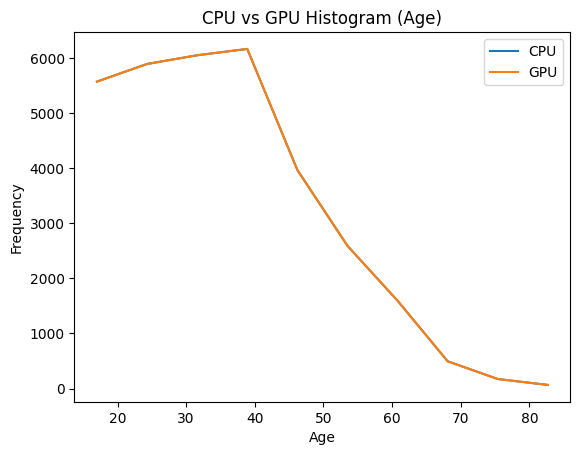

In [17]:
plt.figure()

plt.plot(cpu_bins[:-1], cpu_hist, label="CPU")
plt.plot(cp.asnumpy(gpu_bins[:-1]), cp.asnumpy(gpu_hist), label="GPU")

plt.legend()
plt.title("CPU vs GPU Histogram (Age)")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

In [18]:
quantiles = gdf["age"].quantile([0.25, 0.5, 0.75])

print("Quantiles:\n", quantiles)

Quantiles:
 0.25    28.0
0.50    37.0
0.75    48.0
Name: age, dtype: float64


In [19]:
bins = [0, quantiles[0.25], quantiles[0.5], quantiles[0.75], 100]

gdf["age_bin"] = cudf.cut(gdf["age"], bins=bins, labels=[0,1,2,3])

gdf[["age", "age_bin"]].head()

,age,age_bin
0,39,2
1,50,3
2,38,2
3,53,3
4,28,0


In [20]:
gdf["age_bin"].value_counts()

age_bin
0    8898
2    8241
1    7783
3    7639
Name: count, dtype: int64

In [21]:
# CPU
X = pd.get_dummies(df.drop("income", axis=1))
y = df["income"]

# GPU
gX = cudf.get_dummies(gdf.drop("income", axis=1))
gy = gdf["income"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

gX_train, gX_test, gy_train, gy_test = train_test_split(gX, gy, test_size=0.2)

In [23]:
cpu_model = RandomForestClassifier(n_estimators=100)

cpu_model.fit(X_train, y_train)

cpu_preds = cpu_model.predict(X_test)

cpu_acc = accuracy_score(y_test, cpu_preds)

print("CPU Accuracy:", cpu_acc)

CPU Accuracy: 0.8575157377552587


In [24]:
from cuml.ensemble import RandomForestClassifier as cuRF

gpu_model = cuRF(n_estimators=100)

gpu_model.fit(gX_train, gy_train)

gpu_preds = gpu_model.predict(gX_test)

gpu_acc = accuracy_score(gy_test.to_pandas(), gpu_preds.to_pandas())

print("GPU Accuracy:", gpu_acc)

GPU Accuracy: 0.8613542146476278


In [26]:
import xgboost as xgb

dtrain = xgb.DMatrix(X_train, label=y_train)
dtest = xgb.DMatrix(X_test, label=y_test)

params = {
    "tree_method": "hist",
    "device": "cuda",
    "max_depth": 6,
    "eta": 0.1,
    "objective": "binary:logistic"
}

xgb_model = xgb.train(params, dtrain, num_boost_round=100)

In [27]:
preds = xgb_model.predict(dtest)

pred_labels = [1 if p > 0.5 else 0 for p in preds]

xgb_acc = accuracy_score(y_test, pred_labels)

print("XGBoost GPU Accuracy:", xgb_acc)

XGBoost GPU Accuracy: 0.8679563949025026


In [28]:
print("Final Results:")
print(f"CPU Random Forest Accuracy: {cpu_acc}")
print(f"GPU cuML Random Forest Accuracy: {gpu_acc}")
print(f"XGBoost GPU Accuracy: {xgb_acc}")

Final Results:
CPU Random Forest Accuracy: 0.8575157377552587
GPU cuML Random Forest Accuracy: 0.8613542146476278
XGBoost GPU Accuracy: 0.8679563949025026


Q2. Implement a Random Forest classifier using both scikit-learn (CPU) and RAPIDS cuML
(GPU) on the UCI Breast Cancer Dataset. Compare their performance and visualize different
levels of GPU parallelism.

1.Data Preparation

o Load the dataset using load_breast_cancer().

o Split it into training and testing sets.

o Convert the dataset into cuDF format for GPU processing.

2.CPU Implementation

o Train a Random Forest model using scikit-learn.

o Record training time, prediction time, and accuracy.

3.GPU Implementation

o Train a Random Forest model using RAPIDS cuML.

o Measure training time, prediction time, and accuracy.

o Compute GPU speedup over the CPU.

4.Visualization of Parallelism

o Forest-Level Parallelism: Plot training time vs. number of trees (n_estimators = 1,
10, 50, 100).

o Feature-Level Parallelism: Plot feature importance from the trained model.

o Data-Level Parallelism: Measure training time for varying dataset sizes.

o Bin-Level Parallelism: Demonstrate GPU histogram binning using CuPy.

5.Performance Comparison

o Create a table comparing CPU and GPU results.

o Visualize execution time using bar charts.


In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

import cudf
import cupy as cp
from cuml.ensemble import RandomForestClassifier as cuRF

In [30]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
gX_train = cudf.DataFrame(X_train)
gX_test = cudf.DataFrame(X_test)

gy_train = cudf.Series(y_train.values)
gy_test = cudf.Series(y_test.values)

In [33]:
cpu_model = RandomForestClassifier(n_estimators=100)

# Training time
start = time.time()
cpu_model.fit(X_train, y_train)
cpu_train_time = time.time() - start

# Prediction time
start = time.time()
cpu_preds = cpu_model.predict(X_test)
cpu_pred_time = time.time() - start

cpu_acc = accuracy_score(y_test, cpu_preds)

print("CPU Training Time:", cpu_train_time)
print("CPU Prediction Time:", cpu_pred_time)
print("CPU Accuracy:", cpu_acc)

CPU Training Time: 0.3788599967956543
CPU Prediction Time: 0.021550655364990234
CPU Accuracy: 0.956140350877193


In [34]:
gpu_model = cuRF(n_estimators=100)

# Training time
start = time.time()
gpu_model.fit(gX_train, gy_train)
gpu_train_time = time.time() - start

# Prediction time
start = time.time()
gpu_preds = gpu_model.predict(gX_test)
gpu_pred_time = time.time() - start

gpu_acc = accuracy_score(
    gy_test.to_pandas(),
    gpu_preds.to_pandas()
)

print("GPU Training Time:", gpu_train_time)
print("GPU Prediction Time:", gpu_pred_time)
print("GPU Accuracy:", gpu_acc)

GPU Training Time: 0.30183911323547363
GPU Prediction Time: 0.6092510223388672
GPU Accuracy: 0.9649122807017544


In [35]:
speedup = cpu_train_time / gpu_train_time

print("GPU Speedup over CPU:", speedup)

GPU Speedup over CPU: 1.2551719779937678


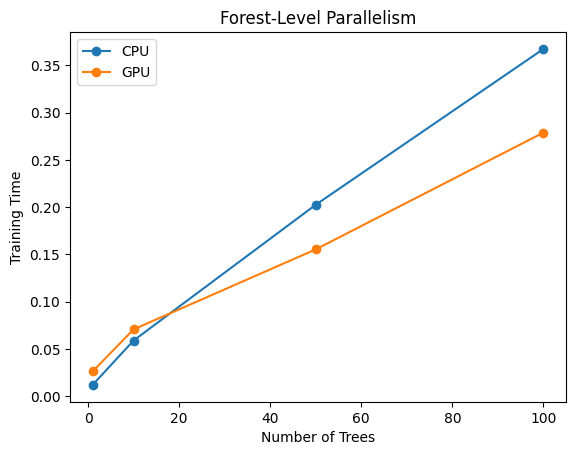

In [36]:
trees = [1, 10, 50, 100]

cpu_times = []
gpu_times = []

for n in trees:
    # CPU
    model = RandomForestClassifier(n_estimators=n)
    start = time.time()
    model.fit(X_train, y_train)
    cpu_times.append(time.time() - start)

    # GPU
    model = cuRF(n_estimators=n)
    start = time.time()
    model.fit(gX_train, gy_train)
    gpu_times.append(time.time() - start)

# Plot
plt.figure()
plt.plot(trees, cpu_times, marker='o', label="CPU")
plt.plot(trees, gpu_times, marker='o', label="GPU")
plt.xlabel("Number of Trees")
plt.ylabel("Training Time")
plt.title("Forest-Level Parallelism")
plt.legend()
plt.show()

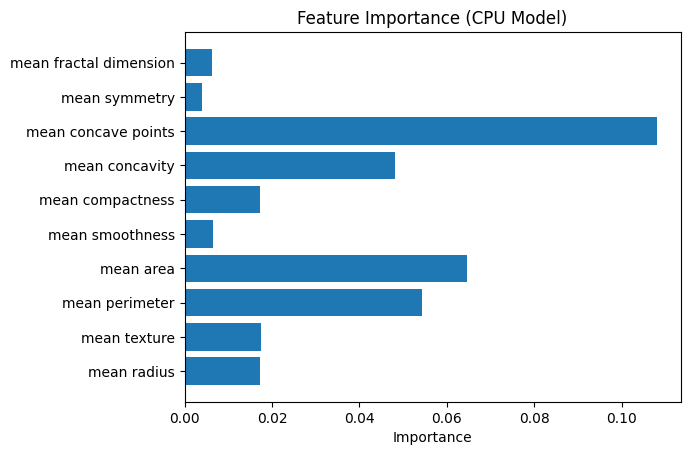

In [37]:
importances = cpu_model.feature_importances_

plt.figure()
plt.barh(X.columns[:10], importances[:10])
plt.title("Feature Importance (CPU Model)")
plt.xlabel("Importance")
plt.show()

/usr/local/lib/python3.12/dist-packages/cuml/ensemble/randomforestclassifier.py:238: UserWarning: The number of bins, `n_bins` is greater than the number of samples used for training. Changing `n_bins` to number of training samples.
  return self._fit_forest(X_m, y_m)


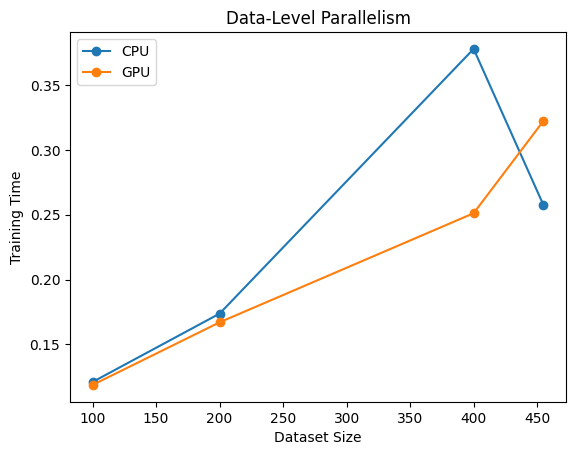

In [38]:
sizes = [100, 200, 400, len(X_train)]

cpu_times = []
gpu_times = []

for size in sizes:
    X_sub = X_train.iloc[:size]
    y_sub = y_train.iloc[:size]

    gX_sub = cudf.DataFrame(X_sub)
    gy_sub = cudf.Series(y_sub.values)

    # CPU
    model = RandomForestClassifier(n_estimators=50)
    start = time.time()
    model.fit(X_sub, y_sub)
    cpu_times.append(time.time() - start)

    # GPU
    model = cuRF(n_estimators=50)
    start = time.time()
    model.fit(gX_sub, gy_sub)
    gpu_times.append(time.time() - start)

# Plot
plt.figure()
plt.plot(sizes, cpu_times, marker='o', label="CPU")
plt.plot(sizes, gpu_times, marker='o', label="GPU")
plt.xlabel("Dataset Size")
plt.ylabel("Training Time")
plt.title("Data-Level Parallelism")
plt.legend()
plt.show()

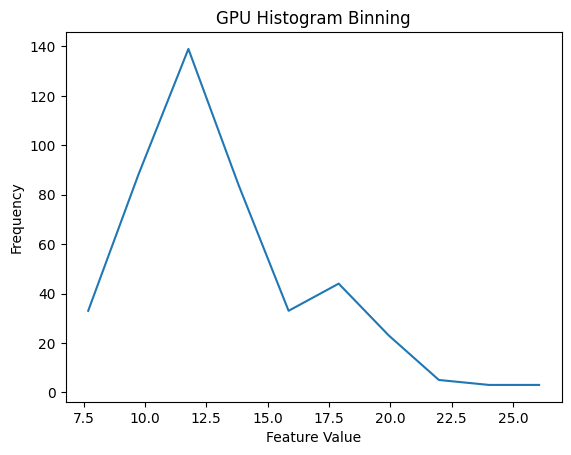

In [39]:
feature = gX_train.iloc[:, 0].to_cupy()

gpu_hist, bins = cp.histogram(feature, bins=10)

plt.figure()
plt.plot(cp.asnumpy(bins[:-1]), cp.asnumpy(gpu_hist))
plt.title("GPU Histogram Binning")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.show()

In [40]:
results = pd.DataFrame({
    "Metric": ["Training Time", "Prediction Time", "Accuracy"],
    "CPU": [cpu_train_time, cpu_pred_time, cpu_acc],
    "GPU": [gpu_train_time, gpu_pred_time, gpu_acc]
})

results

,Metric,CPU,GPU
0,Training Time,0.378860,0.301839
1,Prediction Time,0.021551,0.609251
2,Accuracy,0.956140,0.964912


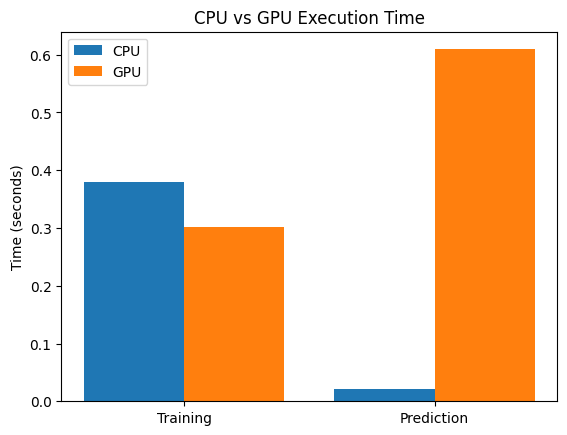

In [41]:
labels = ["Training", "Prediction"]
cpu_vals = [cpu_train_time, cpu_pred_time]
gpu_vals = [gpu_train_time, gpu_pred_time]

x = np.arange(len(labels))

plt.figure()
plt.bar(x - 0.2, cpu_vals, 0.4, label="CPU")
plt.bar(x + 0.2, gpu_vals, 0.4, label="GPU")

plt.xticks(x, labels)
plt.ylabel("Time (seconds)")
plt.title("CPU vs GPU Execution Time")
plt.legend()
plt.show()